In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("/kaggle/input/d/curioso/parking-dataset/parking_dataset.csv")
df["text"] = df["sign"].str.strip() + ". " + df["input_time"].str.strip() + ". " + df["question"].str.strip()
df["label"] = df["label"].astype(int)

In [4]:
# Split into stratified train/test
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

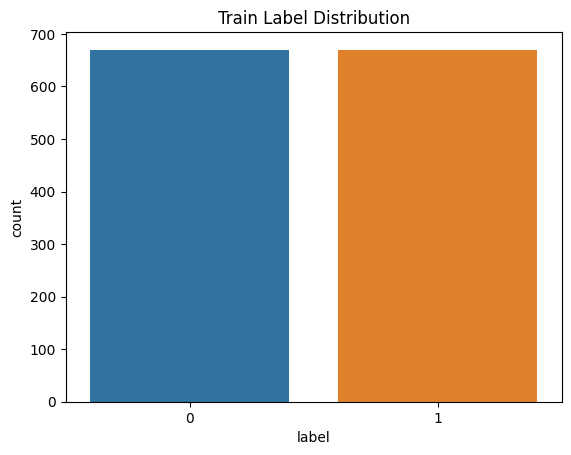

<Figure size 640x480 with 0 Axes>

In [5]:
# Visualize class distribution
sns.countplot(x="label", data=train_df)
plt.title("Train Label Distribution")
plt.savefig("train_label_distribution.png")
plt.show()
plt.clf()

In [6]:
# Initialize vectorizer and models
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}
vectorizer

TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

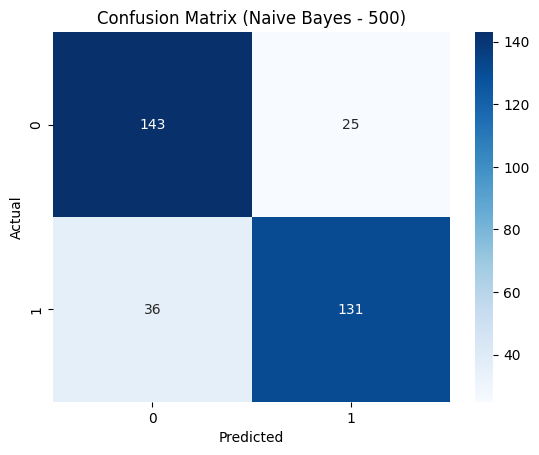

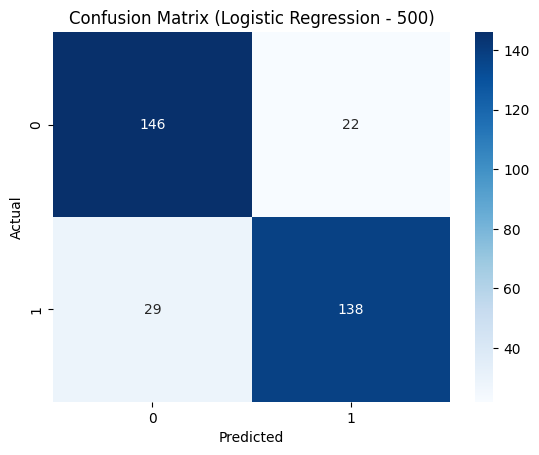

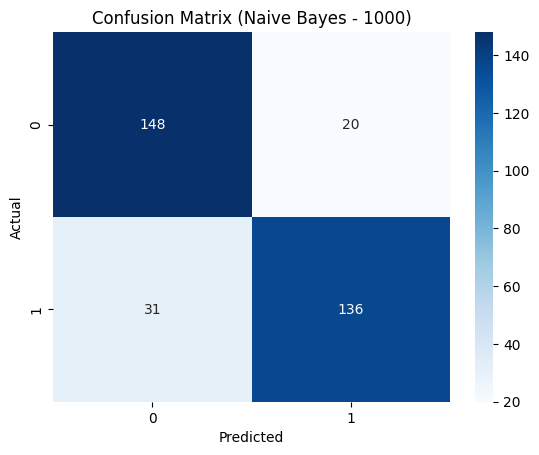

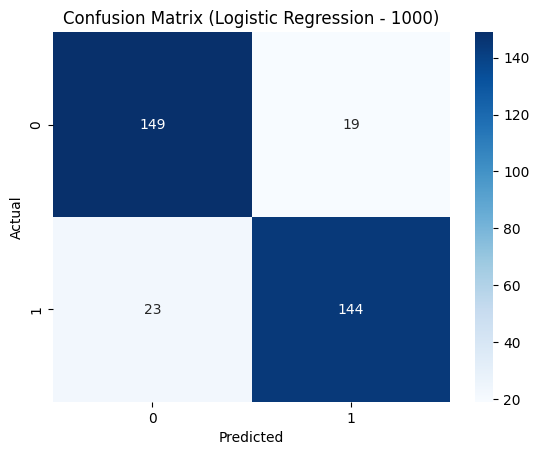

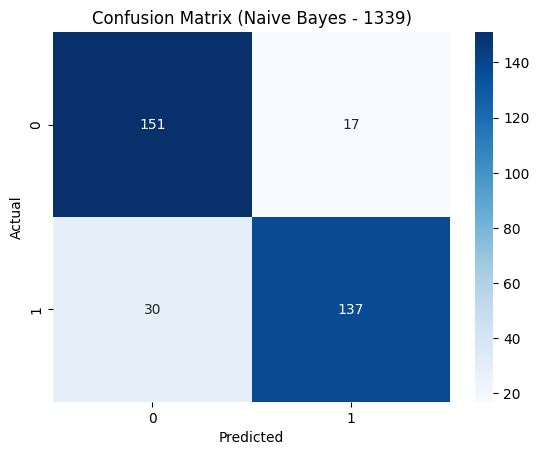

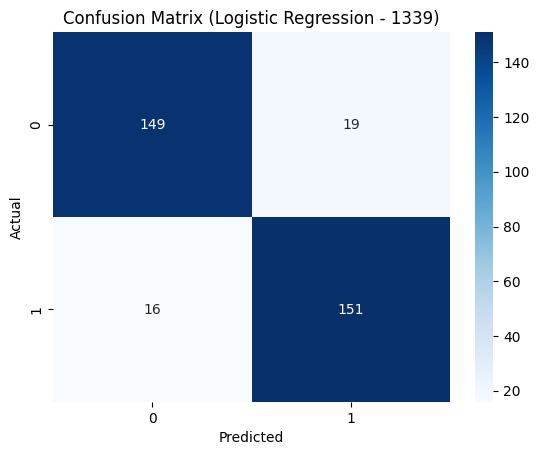

<Figure size 640x480 with 0 Axes>

In [7]:
# Incremental training sizes
increments = [500, 1000, len(train_df)]
results = []

# Evaluate models incrementally
for size in increments:
    subset = train_df.iloc[:size].copy()
    X_train = vectorizer.fit_transform(subset["text"])
    y_train = subset["label"]
    X_test = vectorizer.transform(test_df["text"])
    y_test = test_df["label"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
        specificity = tn / (tn + fp)
        sensitivity = tp / (tp + fn)
        auroc = roc_auc_score(y_test, probs)
        auprc = average_precision_score(y_test, probs)

        metrics = {
            "size": size,
            "model": model_name,
            "accuracy": accuracy_score(y_test, preds),
            "precision": precision_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "f1": f1_score(y_test, preds),
            "specificity": specificity,
            "sensitivity": sensitivity,
            "auroc": auroc,
            "auprc": auprc
        }
        results.append(metrics)

        # Save confusion matrix plot
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix ({model_name} - {size})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
        plt.savefig(f"cm_{model_name.replace(' ', '_').lower()}_{size}.png")
        plt.clf()

In [8]:
# Convert results to DataFrame and save
results_df = pd.DataFrame(results)
results_df.to_csv("baseline_incremental_results.csv", index=False)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

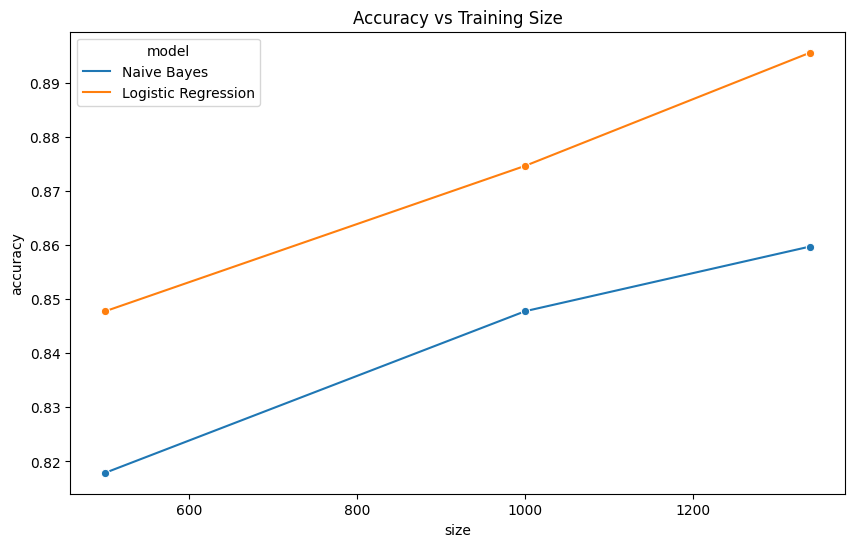

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="size", y="accuracy", hue="model", marker="o")
plt.title("Accuracy vs Training Size")
plt.show()
plt.savefig("accuracy_vs_size.png")
plt.clf()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

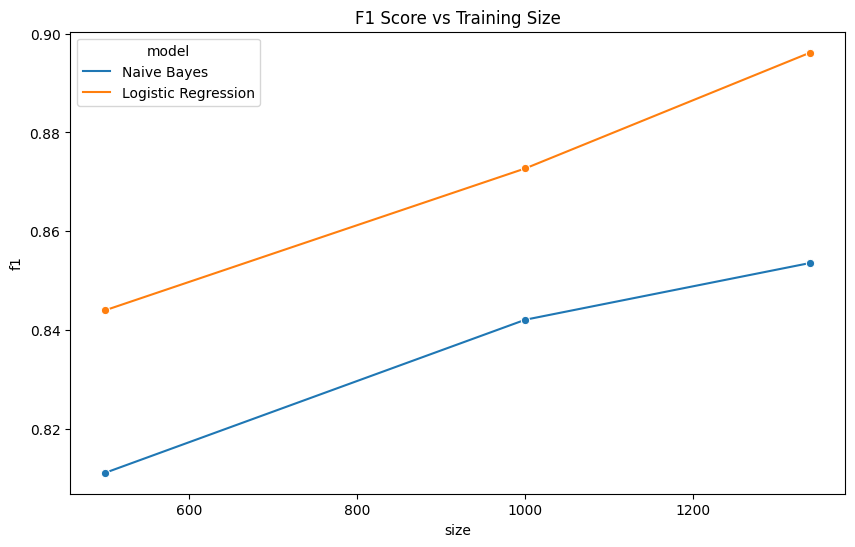

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="size", y="f1", hue="model", marker="o")
plt.title("F1 Score vs Training Size")
plt.show()
plt.savefig("f1_vs_size.png")
plt.clf()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

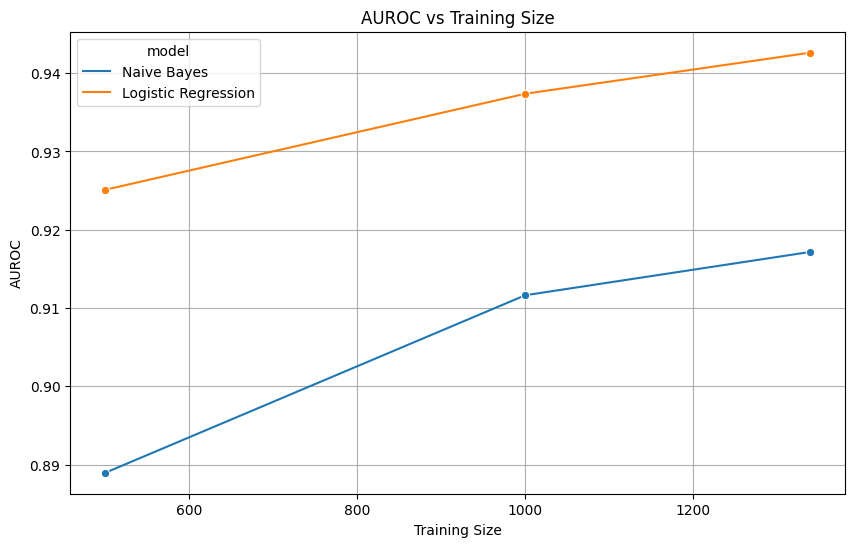

<Figure size 640x480 with 0 Axes>

In [11]:
# Plot AUROC vs Training Size
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="size", y="auroc", hue="model", marker="o")
plt.title("AUROC vs Training Size")
plt.ylabel("AUROC")
plt.xlabel("Training Size")
plt.grid(True)
plt.show()
plt.savefig("auroc_vs_size.png")
plt.clf()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

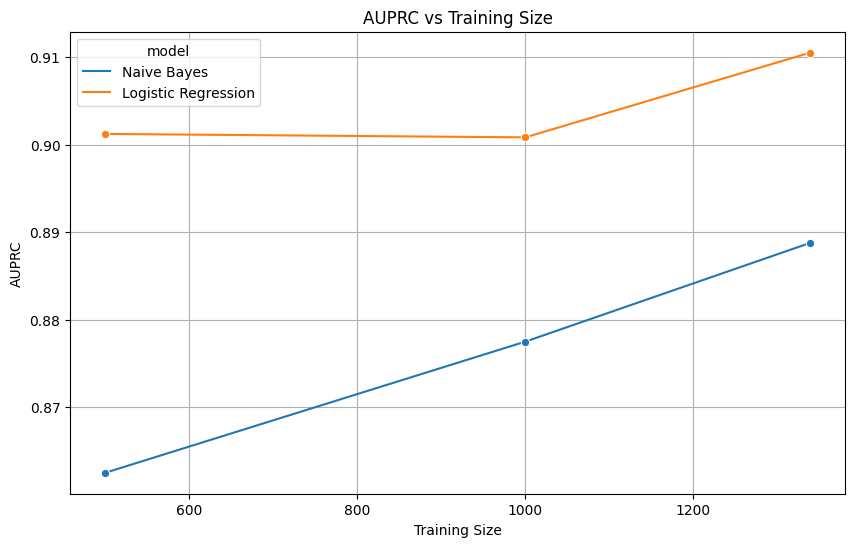

<Figure size 640x480 with 0 Axes>

In [12]:
# Plot AUPRC vs Training Size
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="size", y="auprc", hue="model", marker="o")
plt.title("AUPRC vs Training Size")
plt.ylabel("AUPRC")
plt.xlabel("Training Size")
plt.grid(True)
plt.show()
plt.savefig("auprc_vs_size.png")
plt.clf()